# Survival Analysis
Notebook for survival modeling and evaluation.

In [1]:
# ── 0. imports ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, proportional_hazard_test
from lifelines.utils import concordance_index
import warnings

warnings.filterwarnings("ignore")

matched_df = pd.read_parquet("../data/cohort_matched.parquet")

print(f"Matched cohort: {len(matched_df):,} patients")
print(
    f"Events (deaths): {matched_df['event_observed'].sum():,} "
    f"({matched_df['event_observed'].mean():.1%})"
)
print(f"\nBy group:")
print(
    matched_df.groupby("treatment_label")["event_observed"]
    .agg(["sum", "count", "mean"])
    .rename(columns={"sum": "deaths", "count": "n", "mean": "mortality_rate"})
    .round(3)
)


Matched cohort: 7,832 patients
Events (deaths): 1,934 (24.7%)

By group:
                 deaths     n  mortality_rate
treatment_label                              
fluid_only          845  3916           0.216
vasopressor        1089  3916           0.278


In [2]:
# ── 1. kaplan-meier curves ────────────────────────────────────────────────────

kmf_vasc = KaplanMeierFitter(label="Vasopressor")
kmf_fluid = KaplanMeierFitter(label="Fluid only")

vasc = matched_df[matched_df["treatment_group"] == 1]
fluid = matched_df[matched_df["treatment_group"] == 0]

kmf_vasc.fit(
    durations=vasc["time_to_event_days"], event_observed=vasc["event_observed"]
)
kmf_fluid.fit(
    durations=fluid["time_to_event_days"], event_observed=fluid["event_observed"]
)

# log-rank test
lr = logrank_test(
    vasc["time_to_event_days"],
    fluid["time_to_event_days"],
    event_observed_A=vasc["event_observed"],
    event_observed_B=fluid["event_observed"],
)

print(f"Log-rank test: χ² = {lr.test_statistic:.3f}, p = {lr.p_value:.4f}")

Log-rank test: χ² = 71.272, p = 0.0000


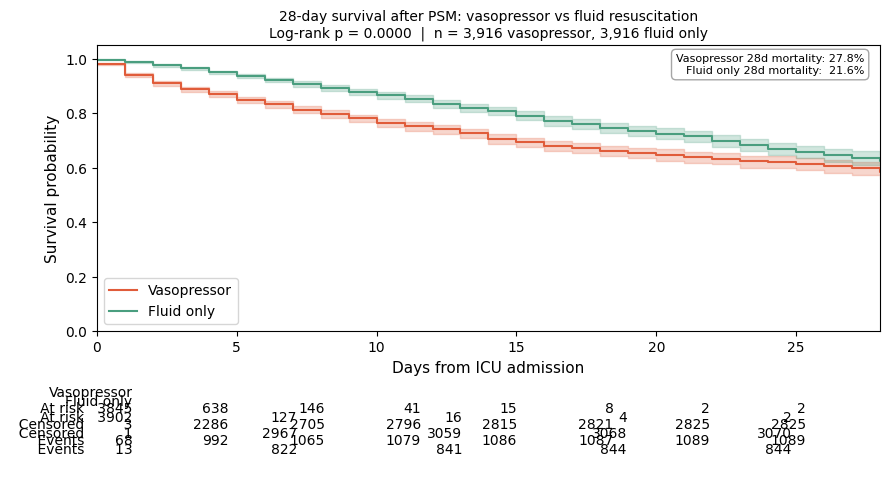

In [3]:
# ── 2. KM plot ────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 5))

kmf_vasc.plot_survival_function(
    ax=ax, ci_show=True, color="#e05c3a", at_risk_counts=True
)
kmf_fluid.plot_survival_function(
    ax=ax, ci_show=True, color="#4a9e7f", at_risk_counts=True
)

ax.set_xlim(0, 28)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Days from ICU admission", fontsize=11)
ax.set_ylabel("Survival probability", fontsize=11)
ax.set_title(
    "28-day survival after PSM: vasopressor vs fluid resuscitation\n"
    f"Log-rank p = {lr.p_value:.4f}  |  "
    f"n = {len(vasc):,} vasopressor, {len(fluid):,} fluid only",
    fontsize=10,
)

# annotation box
textstr = (
    f"Vasopressor 28d mortality: {vasc['event_observed'].mean():.1%}\n"
    f"Fluid only 28d mortality:  {fluid['event_observed'].mean():.1%}"
)
ax.text(
    0.98,
    0.97,
    textstr,
    transform=ax.transAxes,
    fontsize=8,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.7, edgecolor="gray"),
)

plt.tight_layout()
plt.savefig("../figures/03_km_curves_matched.png", dpi=150, bbox_inches="tight")
plt.show()


In [4]:
# ── 3. KM survival probabilities at key timepoints ───────────────────────────
# These numbers go directly into your results writeup

timepoints = [7, 14, 21, 28]

print("=== Survival probability at key timepoints ===")
print(f"{'Timepoint':<12} {'Vasopressor':>14} {'Fluid only':>12}")
print("-" * 40)

for t in timepoints:
    sv = kmf_vasc.survival_function_at_times(t).values[0]
    sf = kmf_fluid.survival_function_at_times(t).values[0]
    print(f"Day {t:<8} {sv:>14.3f} {sf:>12.3f}")


=== Survival probability at key timepoints ===
Timepoint       Vasopressor   Fluid only
----------------------------------------
Day 7                 0.813        0.908
Day 14                0.706        0.808
Day 21                0.638        0.715
Day 28                0.583        0.624


In [8]:
# ── 4. cox proportional hazards model ───────────────────────────────────────-
# Adjust for residual imbalance after matching
# Include the same covariates used in PSM

COX_COVARIATES = [
    "treatment_group",
    "age_at_admission",
    "icu_los_days",
    "total_fluid_ml",
    "bun",
    "creatinine",
    "bilirubin",
    "platelets",
    "wbc",
    "lactate",
    "bicarbonate",
]

cox_df = matched_df[COX_COVARIATES + ["time_to_event_days", "event_observed"]].copy()

# --- Diagnostics & cleaning ---
# coerce covariates to numeric (safely) — convert non-numeric to NaN
for col in COX_COVARIATES:
    cox_df[col] = pd.to_numeric(cox_df[col], errors="coerce")

# report missing and zero counts — helps debug 'deltas may be zero or nans'
print("Missing values per covariate:")
print(cox_df[COX_COVARIATES].isna().sum())
print("Zero values per covariate:")
print((cox_df[COX_COVARIATES] == 0).sum())

# drop constant columns (no variance) — these break the Cox model
const_cols = [c for c in COX_COVARIATES if cox_df[c].nunique(dropna=True) <= 1]
if len(const_cols) > 0:
    print(f"Dropping constant covariates: {const_cols}")
    for c in const_cols:
        COX_COVARIATES.remove(c)
    cox_df.drop(columns=const_cols, inplace=True, errors="ignore")

# drop covariates with very high missingness (>50%) — adjust threshold if needed
missing_frac = cox_df[COX_COVARIATES].isna().mean()
high_missing = missing_frac[missing_frac > 0.5].index.tolist()
if len(high_missing) > 0:
    print(f"Dropping high-missing covariates (>50%): {high_missing}")
    for c in high_missing:
        if c in COX_COVARIATES:
            COX_COVARIATES.remove(c)
    cox_df.drop(columns=high_missing, inplace=True, errors="ignore")

# median imputation for remaining numeric covariates (safe and simple)
if len(COX_COVARIATES) > 0:
    medians = cox_df[COX_COVARIATES].median()
    cox_df[COX_COVARIATES] = cox_df[COX_COVARIATES].fillna(medians)

# drop near-perfectly collinear covariates (abs corr > 0.99)
if len(COX_COVARIATES) > 1:
    corr = cox_df[COX_COVARIATES].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > 0.99)]
    if len(to_drop) > 0:
        print(f"Dropping near-collinear covariates: {to_drop}")
        for c in to_drop:
            if c in COX_COVARIATES:
                COX_COVARIATES.remove(c)
        cox_df.drop(columns=to_drop, inplace=True, errors="ignore")

print(f"Final covariates used for Cox PH: {COX_COVARIATES}")

# ensure outcome columns are present and numeric
cox_df["time_to_event_days"] = pd.to_numeric(
    cox_df["time_to_event_days"], errors="coerce"
)
cox_df["event_observed"] = pd.to_numeric(cox_df["event_observed"], errors="coerce")

# drop rows missing outcome values only (we imputed covariates above)
before_rows = len(cox_df)
cox_df = cox_df.dropna(subset=["time_to_event_days", "event_observed"])
print(
    f"Dropped {before_rows - len(cox_df):,} rows missing outcome; remaining: {len(cox_df):,}"
)

# drop any covariates that still have zero variance after imputation
zero_var = [c for c in COX_COVARIATES if cox_df[c].std() == 0]
if len(zero_var) > 0:
    print(f"Dropping zero-variance covariates: {zero_var}")
    for c in zero_var:
        COX_COVARIATES.remove(c)
    cox_df.drop(columns=zero_var, inplace=True, errors="ignore")

if len(COX_COVARIATES) == 0:
    raise ValueError("No valid covariates remain for Cox model after cleaning.")

# final fit
cph = CoxPHFitter(penalizer=0.1)  # small L2 penalty for stability
cph.fit(
    cox_df[COX_COVARIATES + ["time_to_event_days", "event_observed"]],
    duration_col="time_to_event_days",
    event_col="event_observed",
    show_progress=False,
)

cph.print_summary(decimals=3)


Missing values per covariate:
treatment_group     0
age_at_admission    0
icu_los_days        0
total_fluid_ml      0
bun                 0
creatinine          0
bilirubin           0
platelets           0
wbc                 0
lactate             0
bicarbonate         0
dtype: int64
Zero values per covariate:
treatment_group     3916
age_at_admission       0
icu_los_days           0
total_fluid_ml      7832
bun                    0
creatinine             0
bilirubin              0
platelets              0
wbc                    0
lactate                0
bicarbonate            0
dtype: Int64
Dropping constant covariates: ['total_fluid_ml']
Final covariates used for Cox PH: ['treatment_group', 'age_at_admission', 'icu_los_days', 'bun', 'creatinine', 'bilirubin', 'platelets', 'wbc', 'lactate', 'bicarbonate']
Dropped 0 rows missing outcome; remaining: 7,832


<lifelines.CoxPHFitter: fitted with 7832 total observations, 5898 right-censored observations>
             duration col = 'time_to_event_days'
                event col = 'event_observed'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 7832
number of events observed = 1934
   partial log-likelihood = -15571.432
         time fit was run = 2026-05-21 07:22:01 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
treatment_group   0.315     1.370     0.039           0.239           0.390               1.270               1.477
age_at_admission  0.013     1.013     0.001           0.010           0.016               1.010               1.016
icu_los_days     -0.021     0.980     0.003          -0.026          -0.015               0.974               0.985
bun               0.006     1.006     0.001           0.004           0.008               1.004               1.008
creatinine        0.006     1.006     0.014          -0.022           0.033               0.978               1.033
bilirubin         0.019     1.019     0.004           0.011           0.027               1.011               1.027
platelets        -0.001     0.999     0.000          -0.001          -0.000               0.999               1.000
wbc              -0.002     0.998     0.002          -0.006           0.002               0.994               1.002
lactate           0.130     1.138     0.010           0.109           0.150               1.115               1.162
bicarbonate       0.003     1.003     0.005          -0.006           0.012               0.994               1.012

                  cmp to      z       p  -log2(p)
covariate                                        
treatment_group    0.000  8.140 <0.0005    51.167
age_at_admission   0.000  9.435 <0.0005    67.794
icu_los_days       0.000 -7.768 <0.0005    46.833
bun                0.000  7.005 <0.0005    38.558
creatinine         0.000  0.396   0.692     0.531
bilirubin          0.000  4.622 <0.0005    18.005
platelets          0.000 -3.160   0.002     9.310
wbc                0.000 -1.145   0.252     1.988
lactate            0.000 12.391 <0.0005   114.722
bicarbonate        0.000  0.633   0.527     0.925
---
Concordance = 0.699
Partial AIC = 31162.863
log-likelihood ratio test = 444.697 on 10 df
-log2(p) of ll-ratio test = 294.154

In [9]:
# ── 5. extract and format hazard ratio table ──────────────────────────────────
# This is your primary results table

summary = cph.summary.copy()
summary = summary[
    ["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]
].copy()
summary.columns = ["HR", "CI_lower", "CI_upper", "p_value"]
summary = summary.round(3)

print("=== Cox PH results — hazard ratios ===")
print(summary.to_string())

# pull out the treatment effect specifically
hr_row = summary.loc["treatment_group"]
print(f"\n=== Primary result ===")
print(f"Treatment HR:  {hr_row['HR']:.3f}")
print(f"95% CI:        [{hr_row['CI_lower']:.3f}, {hr_row['CI_upper']:.3f}]")
print(f"p-value:       {hr_row['p_value']:.4f}")

direction = "higher" if hr_row["HR"] > 1 else "lower"
print(
    f"\nInterpretation: vasopressor use was associated with "
    f"{direction} hazard of 28-day mortality "
    f"(HR {hr_row['HR']:.2f}, 95% CI {hr_row['CI_lower']:.2f}–"
    f"{hr_row['CI_upper']:.2f}, p={hr_row['p_value']:.3f}) "
    f"compared to fluid resuscitation alone, after propensity score matching."
)


=== Cox PH results — hazard ratios ===
                     HR  CI_lower  CI_upper  p_value
covariate                                           
treatment_group   1.370     1.270     1.477    0.000
age_at_admission  1.013     1.010     1.016    0.000
icu_los_days      0.980     0.974     0.985    0.000
bun               1.006     1.004     1.008    0.000
creatinine        1.006     0.978     1.033    0.692
bilirubin         1.019     1.011     1.027    0.000
platelets         0.999     0.999     1.000    0.002
wbc               0.998     0.994     1.002    0.252
lactate           1.138     1.115     1.162    0.000
bicarbonate       1.003     0.994     1.012    0.527

=== Primary result ===
Treatment HR:  1.370
95% CI:        [1.270, 1.477]
p-value:       0.0000

Interpretation: vasopressor use was associated with higher hazard of 28-day mortality (HR 1.37, 95% CI 1.27–1.48, p=0.000) compared to fluid resuscitation alone, after propensity score matching.


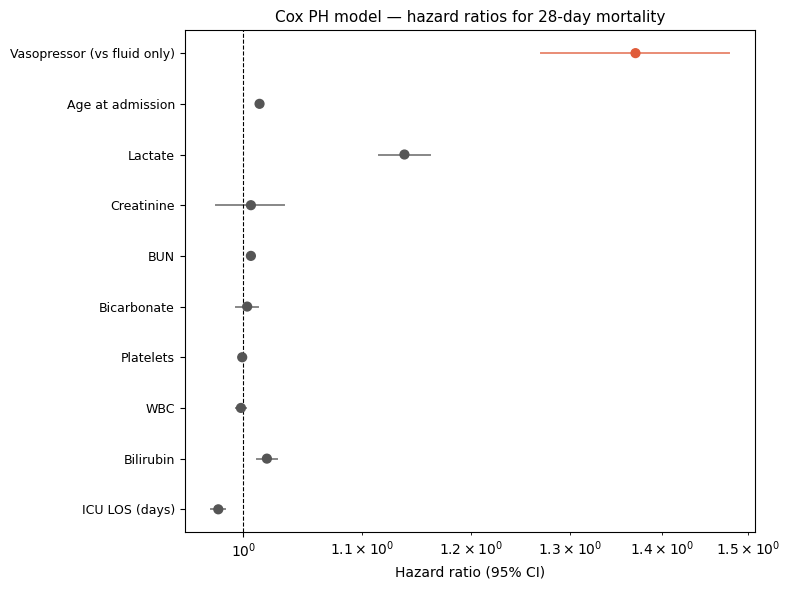

In [13]:
# ── 6. forest plot of hazard ratios ───────────────────────────────────────────

plot_vars = [
    "treatment_group",
    "age_at_admission",
    "lactate",
    "creatinine",
    "bun",
    "bicarbonate",
    "platelets",
    "wbc",
    "bilirubin",
    "total_fluid_ml",
    "icu_los_days",
]

labels = {
    "treatment_group": "Vasopressor (vs fluid only)",
    "age_at_admission": "Age at admission",
    "lactate": "Lactate",
    "creatinine": "Creatinine",
    "bun": "BUN",
    "bicarbonate": "Bicarbonate",
    "platelets": "Platelets",
    "wbc": "WBC",
    "bilirubin": "Bilirubin",
    "total_fluid_ml": "Total fluid (mL)",
    "icu_los_days": "ICU LOS (days)",
}

plot_df = summary.loc[
    [p for p in plot_vars if p in summary.index]
].copy()  # filter to vars in plot_vars, preserving order since some may have been dropped during cleaning

plot_df["label"] = [labels[v] for v in plot_vars if v in summary.index]
plot_df = plot_df.iloc[::-1]  # flip for readability

fig, ax = plt.subplots(figsize=(8, 6))

y_pos = range(len(plot_df))
colors = ["#e05c3a" if v == "treatment_group" else "#555555" for v in plot_df.index]

ax.scatter(plot_df["HR"], y_pos, color=colors, zorder=3, s=40)

for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.plot(
        [row["CI_lower"], row["CI_upper"]],
        [i, i],
        color=colors[i],
        linewidth=1.4,
        alpha=0.7,
    )

ax.axvline(1.0, color="black", linestyle="--", linewidth=0.8)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(plot_df["label"], fontsize=9)
ax.set_xlabel("Hazard ratio (95% CI)", fontsize=10)
ax.set_title("Cox PH model — hazard ratios for 28-day mortality", fontsize=11)
ax.set_xscale("log")  # log scale is standard for HR forest plots

plt.tight_layout()
plt.savefig("../figures/03_forest_plot.png", dpi=150, bbox_inches="tight")
plt.show()


In [14]:
# ── 7. proportional hazards assumption test ───────────────────────────────────
# Critical diagnostic — Cox PH is only valid if hazards are proportional
# Schoenfeld residuals test: p > 0.05 means PH assumption holds

ph_test = proportional_hazard_test(cph, cox_df, time_transform="rank")

print("=== Schoenfeld residuals test (proportional hazards) ===")
print("H0: hazards are proportional (p > 0.05 = assumption holds)")
print()
print(ph_test.summary.round(3).to_string())

violations = ph_test.summary[ph_test.summary["p"] < 0.05]
if len(violations) > 0:
    print(f"\n⚠ PH assumption violated for: {list(violations.index)}")
    print("  Consider: time-varying coefficients or stratified Cox model")
else:
    print("\n✓ PH assumption holds for all covariates")


=== Schoenfeld residuals test (proportional hazards) ===
H0: hazards are proportional (p > 0.05 = assumption holds)

                  test_statistic      p  -log2(p)
age_at_admission           0.383  0.536     0.900
bicarbonate                3.507  0.061     4.032
bilirubin                  1.491  0.222     2.171
bun                        2.992  0.084     3.579
creatinine                 0.002  0.964     0.054
icu_los_days             126.087  0.000    94.779
lactate                   47.154  0.000    37.149
platelets                  0.246  0.620     0.691
treatment_group          127.347  0.000    95.695
wbc                        0.298  0.585     0.773

⚠ PH assumption violated for: ['icu_los_days', 'lactate', 'treatment_group']
  Consider: time-varying coefficients or stratified Cox model


In [15]:
# ── 8. model discrimination ───────────────────────────────────────────────────
# C-statistic (concordance index) — analogous to AUC for survival models
# > 0.7 is considered acceptable, > 0.8 is good

c_index = concordance_index(
    cox_df["time_to_event_days"],
    -cph.predict_partial_hazard(cox_df),
    cox_df["event_observed"],
)

print(f"C-statistic (concordance index): {c_index:.3f}")

if c_index >= 0.8:
    print("→ Good discrimination")
elif c_index >= 0.7:
    print("→ Acceptable discrimination")
else:
    print("→ Poor discrimination — consider enriching covariate set")


C-statistic (concordance index): 0.699
→ Poor discrimination — consider enriching covariate set


In [16]:
# ── 9. sensitivity analysis — crude vs adjusted ───────────────────────────────
# Shows the magnitude of confounding your PSM removed
# Important for the writeup — before/after comparison tells the story

# crude model — treatment only, no covariates, unmatched data
unmatched = pd.read_parquet("../data/cohort_raw.parquet").dropna(
    subset=["time_to_event_days", "event_observed", "treatment_group"]
)

cph_crude = CoxPHFitter()
cph_crude.fit(
    unmatched[["treatment_group", "time_to_event_days", "event_observed"]],
    duration_col="time_to_event_days",
    event_col="event_observed",
    show_progress=False,
)

hr_crude = cph_crude.summary.loc["treatment_group", "exp(coef)"]
hr_adjusted = summary.loc["treatment_group", "HR"]

print("=== Sensitivity: crude vs adjusted HR ===")
print(f"Crude HR (unadjusted, unmatched): {hr_crude:.3f}")
print(f"Adjusted HR (PSM + covariates):   {hr_adjusted:.3f}")
print(
    f"\nConfounding accounted for: "
    f"{abs(hr_crude - hr_adjusted) / hr_crude:.1%} shift in HR"
)


=== Sensitivity: crude vs adjusted HR ===
Crude HR (unadjusted, unmatched): 1.747
Adjusted HR (PSM + covariates):   1.370

Confounding accounted for: 21.6% shift in HR


In [17]:
# ── 10. save results ──────────────────────────────────────────────────────────

results = {
    "n_matched_total": len(matched_df),
    "n_vasopressor": len(vasc),
    "n_fluid_only": len(fluid),
    "mortality_vasopressor": vasc["event_observed"].mean().round(4),
    "mortality_fluid_only": fluid["event_observed"].mean().round(4),
    "logrank_p": round(lr.p_value, 4),
    "hr_treatment": hr_row["HR"],
    "hr_ci_lower": hr_row["CI_lower"],
    "hr_ci_upper": hr_row["CI_upper"],
    "hr_p_value": hr_row["p_value"],
    "c_index": round(c_index, 3),
    "hr_crude": round(hr_crude, 3),
    "hr_adjusted": round(hr_adjusted, 3),
}

pd.Series(results).to_json("../data/results_summary.json")
print("Saved results_summary.json")

print("\n=== Notebook 03 complete ===")
print("Next step: 04_shap.ipynb — model interpretability")
print(
    f"\nPrimary result: HR {hr_row['HR']:.2f} "
    f"(95% CI {hr_row['CI_lower']:.2f}–{hr_row['CI_upper']:.2f}, "
    f"p={hr_row['p_value']:.3f})"
)


Saved results_summary.json

=== Notebook 03 complete ===
Next step: 04_shap.ipynb — model interpretability

Primary result: HR 1.37 (95% CI 1.27–1.48, p=0.000)
